# Crop Yield Prediction - Exploratory Data Analysis (EDA)

## 📊 Phân tích Khám Phá Dữ Liệu

Notebook này thực hiện phân tích khám phá (EDA) toàn diện trên dataset dự báo năng suất cây trồng.

### Nội Dung:
1. **Data Loading** - Tải dữ liệu từ file CSV
2. **Data Overview** - Kiểm tra thông tin cơ bản về dữ liệu
3. **Statistical Analysis** - Phân tích thống kê
4. **Distribution Analysis** - Phân tích phân bố
5. **Correlation Analysis** - Phân tích tương quan
6. **Missing Values** - Kiểm tra missing values
7. **Visualizations** - Vẽ các biểu đồ

---

## 1. Data Loading and Overview

In [25]:
# Import các thư viện cần thiết
import sys
from pathlib import Path

# Thêm src vào path để có thể import modules
src_path = Path('../src')
sys.path.insert(0, str(src_path.absolute()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Cấu hình matplotlib
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Đã import tất cả các thư viện cần thiết")

✓ Đã import tất cả các thư viện cần thiết


In [26]:
# Tải dữ liệu từ các file CSV (CLEANED DATA)
data_dir = Path('../data/raw/cleaned')

print("✓ Sử dụng cleaned data")
df_yield = pd.read_csv(data_dir / 'yield_cleaned.csv')
df_pesticides = pd.read_csv(data_dir / 'pesticides_cleaned.csv')
df_rainfall = pd.read_csv(data_dir / 'rainfall_cleaned.csv')
df_temperature = pd.read_csv(data_dir / 'temp_cleaned.csv')

print("📂 Đã tải các file dữ liệu:")
print(f"  • yield_cleaned.csv: {df_yield.shape}")
print(f"  • pesticides_cleaned.csv: {df_pesticides.shape}")
print(f"  • rainfall_cleaned.csv: {df_rainfall.shape}")
print(f"  • temp_cleaned.csv: {df_temperature.shape}")

✓ Sử dụng cleaned data


📂 Đã tải các file dữ liệu:
  • yield_cleaned.csv: (56717, 12)
  • pesticides_cleaned.csv: (4349, 7)
  • rainfall_cleaned.csv: (5947, 3)
  • temp_cleaned.csv: (68764, 3)


In [27]:
# Kiểm tra cấu trúc dữ liệu trước merge
print("🔍 Kiểm tra cấu trúc các dataframes:")
print(f"\ndf_yield columns: {df_yield.columns.tolist()}")
print(f"df_yield shape: {df_yield.shape}")
print(f"\ndf_pesticides columns: {df_pesticides.columns.tolist()}")
print(f"df_pesticides shape: {df_pesticides.shape}")
print(f"\ndf_rainfall columns: {df_rainfall.columns.tolist()}")
print(f"df_rainfall shape: {df_rainfall.shape}")
print(f"\ndf_temperature columns: {df_temperature.columns.tolist()}")
print(f"df_temperature shape: {df_temperature.shape}")

# Chuẩn hóa tên cột
df_temperature = df_temperature.rename(columns={'year': 'Year', 'country': 'Area'})
df_rainfall.columns = df_rainfall.columns.str.strip()  # Loại bỏ khoảng trắng ở đầu/cuối
df_rainfall = df_rainfall.rename(columns={'Area': 'Area'})

print("\n✓ Đã chuẩn hóa tên cột")

# Kết hợp tất cả các dataset - lấy những records có đủ từng Area và Year
# Bắt đầu với yield
df = df_yield[['Year', 'Area', 'Value']].rename(columns={'Value': 'Yield'}).copy()

print(f"\nBắt đầu với df_yield: {df.shape}")
print(f"Unique areas in yield: {df['Area'].nunique()}")
print(f"Unique years in yield: {df['Year'].nunique()}")

# Merge với pesticides
if df_pesticides.shape[0] > 0:
    df_pest_renamed = df_pesticides[['Year', 'Area', 'Value']].rename(columns={'Value': 'Pesticides'})
    df = pd.merge(df, df_pest_renamed, on=['Year', 'Area'], how='inner')
    print(f"Sau merge pesticides: {df.shape}")

# Merge với rainfall
if df_rainfall.shape[0] > 0:
    df_rain_renamed = df_rainfall.rename(columns={'average_rain_fall_mm_per_year': 'Rainfall'})
    print(f"Rainfall columns after rename: {df_rain_renamed.columns.tolist()}")
    df = pd.merge(df, df_rain_renamed[['Year', 'Area', 'Rainfall']], on=['Year', 'Area'], how='inner')
    print(f"Sau merge rainfall: {df.shape}")

# Merge với temperature
if df_temperature.shape[0] > 0:
    df_temp_renamed = df_temperature[['Year', 'Area', 'avg_temp']].rename(columns={'avg_temp': 'Temperature'})
    df = pd.merge(df, df_temp_renamed, on=['Year', 'Area'], how='inner')
    print(f"Sau merge temperature: {df.shape}")

print(f"\n📊 Dataset sau kết hợp: {df.shape}")
print(f"   Hàng: {df.shape[0]}, Cột: {df.shape[1]}")

🔍 Kiểm tra cấu trúc các dataframes:

df_yield columns: ['Domain Code', 'Domain', 'Area Code', 'Area', 'Element Code', 'Element', 'Item Code', 'Item', 'Year Code', 'Year', 'Unit', 'Value']
df_yield shape: (56717, 12)

df_pesticides columns: ['Domain', 'Area', 'Element', 'Item', 'Year', 'Unit', 'Value']
df_pesticides shape: (4349, 7)

df_rainfall columns: [' Area', 'Year', 'average_rain_fall_mm_per_year']
df_rainfall shape: (5947, 3)

df_temperature columns: ['year', 'country', 'avg_temp']
df_temperature shape: (68764, 3)

✓ Đã chuẩn hóa tên cột

Bắt đầu với df_yield: (56717, 3)
Unique areas in yield: 212
Unique years in yield: 56
Sau merge pesticides: (24153, 4)
Rainfall columns after rename: ['Area', 'Year', 'Rainfall']
Sau merge rainfall: (18949, 5)
Sau merge temperature: (28242, 6)

📊 Dataset sau kết hợp: (28242, 6)
   Hàng: 28242, Cột: 6


In [28]:
# Hiển thị 5 dòng đầu tiên
print("🔍 5 Dòng Đầu Tiên Của Dataset:")
display(df.head())

print("\n✓ Các Cột Trong Dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col} ({df[col].dtype})")

🔍 5 Dòng Đầu Tiên Của Dataset:


,Year,Area,Yield,Pesticides,Rainfall,Temperature
0,1990,Albania,36613,121.0,1485.0,16.37
1,1990,Albania,66667,121.0,1485.0,16.37
2,1990,Albania,23333,121.0,1485.0,16.37
3,1990,Albania,12500,121.0,1485.0,16.37
4,1990,Albania,7000,121.0,1485.0,16.37



✓ Các Cột Trong Dataset:
   1. Year (int64)
   2. Area (object)
   3. Yield (int64)
   4. Pesticides (float64)
   5. Rainfall (float64)
   6. Temperature (float64)


In [29]:
# Thông tin chi tiết về dataset
print("\n" + "="*80)
print("📋 THÔNG TIN CHI TIẾT VỀ DATASET")
print("="*80)

# Shape
print(f"\nShape: {df.shape[0]} dòng × {df.shape[1]} cột")

# Memory usage
print(f"\nMemory Usage: {df.memory_usage().sum() / 1024:.2f} KB")

# Data types
print("\nLoại Dữ Liệu:")
print(df.dtypes)

# Info
print("\nThông Tin Đầy Đủ:")
df.info()


📋 THÔNG TIN CHI TIẾT VỀ DATASET

Shape: 28242 dòng × 6 cột

Memory Usage: 1323.97 KB

Loại Dữ Liệu:
Year             int64
Area            object
Yield            int64
Pesticides     float64
Rainfall       float64
Temperature    float64
dtype: object

Thông Tin Đầy Đủ:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         28242 non-null  int64  
 1   Area         28242 non-null  object 
 2   Yield        28242 non-null  int64  
 3   Pesticides   28242 non-null  float64
 4   Rainfall     28242 non-null  float64
 5   Temperature  28242 non-null  float64
dtypes: float64(3), int64(2), object(1)
memory usage: 1.3+ MB


## 2. Statistical Analysis

In [30]:
# Thống kê mô tả
print("\n" + "="*80)
print("📊 THỐNG KÊ MÔ TẢ")
print("="*80)

stats = df.describe()
display(stats.T)  # Transpose để dễ xem


📊 THỐNG KÊ MÔ TẢ


,count,mean,std,min,25%,50%,75%,max
Year,28242.0,2001.544296,7.051905,1990.00,1995.0000,2001.00,2008.00,2013.00
Yield,28242.0,77053.332094,84956.612897,50.00,19919.2500,38295.00,104676.75,501412.00
Pesticides,28242.0,37076.909344,59958.784665,0.04,1702.0000,17529.44,48687.88,367778.00
Rainfall,28242.0,1149.055980,709.812150,51.00,593.0000,1083.00,1668.00,3240.00
Temperature,28242.0,20.542627,6.312051,1.30,16.7025,21.51,26.00,30.65


In [31]:
# Thống kê cho từng feature
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("\n📈 Thống Kê Chi Tiết Cho Từng Feature:")

for col in numeric_cols:
    print(f"\n{col}:")
    print(f"  • Giá trị min: {df[col].min():.2f}")
    print(f"  • Giá trị max: {df[col].max():.2f}")
    print(f"  • Giá trị mean: {df[col].mean():.2f}")
    print(f"  • Giá trị median: {df[col].median():.2f}")
    print(f"  • Độ lệch chuẩn: {df[col].std():.2f}")
    print(f"  • Skewness: {df[col].skew():.2f}")
    print(f"  • Kurtosis: {df[col].kurtosis():.2f}")


📈 Thống Kê Chi Tiết Cho Từng Feature:

Year:
  • Giá trị min: 1990.00
  • Giá trị max: 2013.00
  • Giá trị mean: 2001.54
  • Giá trị median: 2001.00
  • Độ lệch chuẩn: 7.05
  • Skewness: 0.01
  • Kurtosis: -1.27

Yield:
  • Giá trị min: 50.00
  • Giá trị max: 501412.00
  • Giá trị mean: 77053.33
  • Giá trị median: 38295.00
  • Độ lệch chuẩn: 84956.61
  • Skewness: 1.79
  • Kurtosis: 3.07

Pesticides:
  • Giá trị min: 0.04
  • Giá trị max: 367778.00
  • Giá trị mean: 37076.91
  • Giá trị median: 17529.44
  • Độ lệch chuẩn: 59958.78
  • Skewness: 3.49
  • Kurtosis: 14.01

Rainfall:
  • Giá trị min: 51.00
  • Giá trị max: 3240.00
  • Giá trị mean: 1149.06
  • Giá trị median: 1083.00
  • Độ lệch chuẩn: 709.81
  • Skewness: 0.85
  • Kurtosis: 0.31

Temperature:
  • Giá trị min: 1.30
  • Giá trị max: 30.65
  • Giá trị mean: 20.54
  • Giá trị median: 21.51
  • Độ lệch chuẩn: 6.31
  • Skewness: -0.74
  • Kurtosis: -0.42


## 3. Missing Values Analysis

In [32]:
# Kiểm tra missing values
print("\n" + "="*80)
print("⚠️  KIỂM TRA MISSING VALUES")
print("="*80)

missing_info = pd.DataFrame({
    'Cột': df.columns,
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2),
    'Data Type': df.dtypes
})

display(missing_info)

if df.isnull().sum().sum() == 0:
    print("\n✓ Không có missing values!")
else:
    print(f"\n⚠️  Tổng missing values: {df.isnull().sum().sum()}")


⚠️  KIỂM TRA MISSING VALUES


,Cột,Missing Count,Missing %,Data Type
Year,Year,0,0.0,int64
Area,Area,0,0.0,object
Yield,Yield,0,0.0,int64
Pesticides,Pesticides,0,0.0,float64
Rainfall,Rainfall,0,0.0,float64
Temperature,Temperature,0,0.0,float64



✓ Không có missing values!


In [33]:
# Visualize missing values
missing_data = df.isnull().sum()

if missing_data.sum() == 0:
    print("✓ Không có missing values - không cần vẽ biểu đồ")
else:
    fig, ax = plt.subplots(figsize=(12, 4))
    
    missing_pct = (missing_data / len(df) * 100)
    
    missing_data[missing_data > 0].plot(kind='bar', ax=ax, color='coral')
    ax.set_title('Missing Values By Column', fontsize=14, fontweight='bold')
    ax.set_ylabel('Count', fontsize=12)
    ax.set_xlabel('Column', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Biểu đồ missing values đã vẽ")

✓ Không có missing values - không cần vẽ biểu đồ


## 4. Distribution Analysis


📊 PHÂN BỐ CỦA YIELD (TARGET VARIABLE)


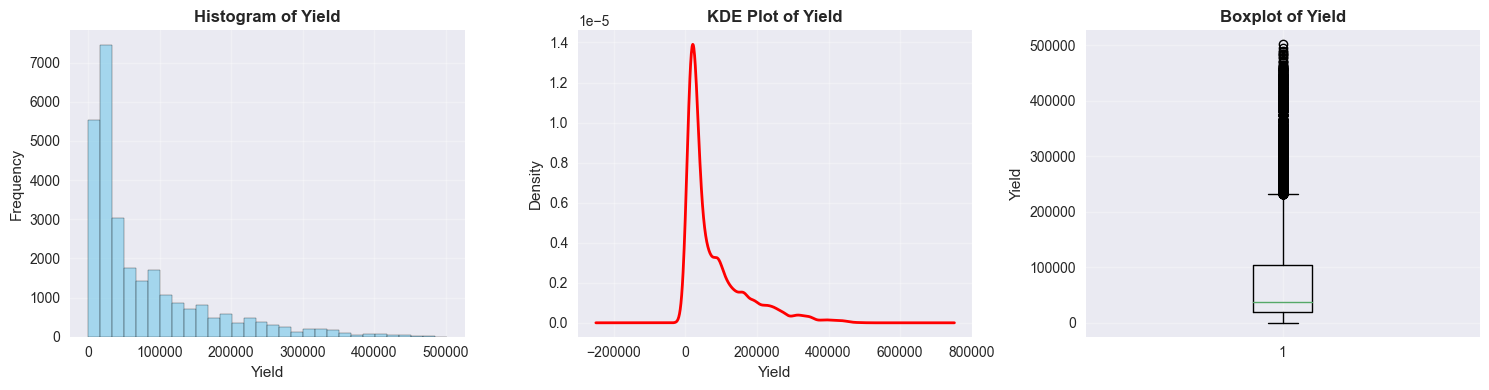

In [34]:
# Phân bố của Yield (target variable)
print("\n" + "="*80)
print("📊 PHÂN BỐ CỦA YIELD (TARGET VARIABLE)")
print("="*80)

target_col = 'Yield'
if target_col in df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Histogram
    axes[0].hist(df[target_col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0].set_title('Histogram of Yield', fontsize=12, fontweight='bold')
    axes[0].set_xlabel(target_col)
    axes[0].set_ylabel('Frequency')
    axes[0].grid(alpha=0.3)
    
    # KDE Plot
    df[target_col].plot(kind='kde', ax=axes[1], color='red', linewidth=2)
    axes[1].set_title('KDE Plot of Yield', fontsize=12, fontweight='bold')
    axes[1].set_xlabel(target_col)
    axes[1].grid(alpha=0.3)
    
    # Boxplot
    axes[2].boxplot(df[target_col], vert=True)
    axes[2].set_title('Boxplot of Yield', fontsize=12, fontweight='bold')
    axes[2].set_ylabel(target_col)
    axes[2].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠️  Cột {target_col} không tìm thấy")

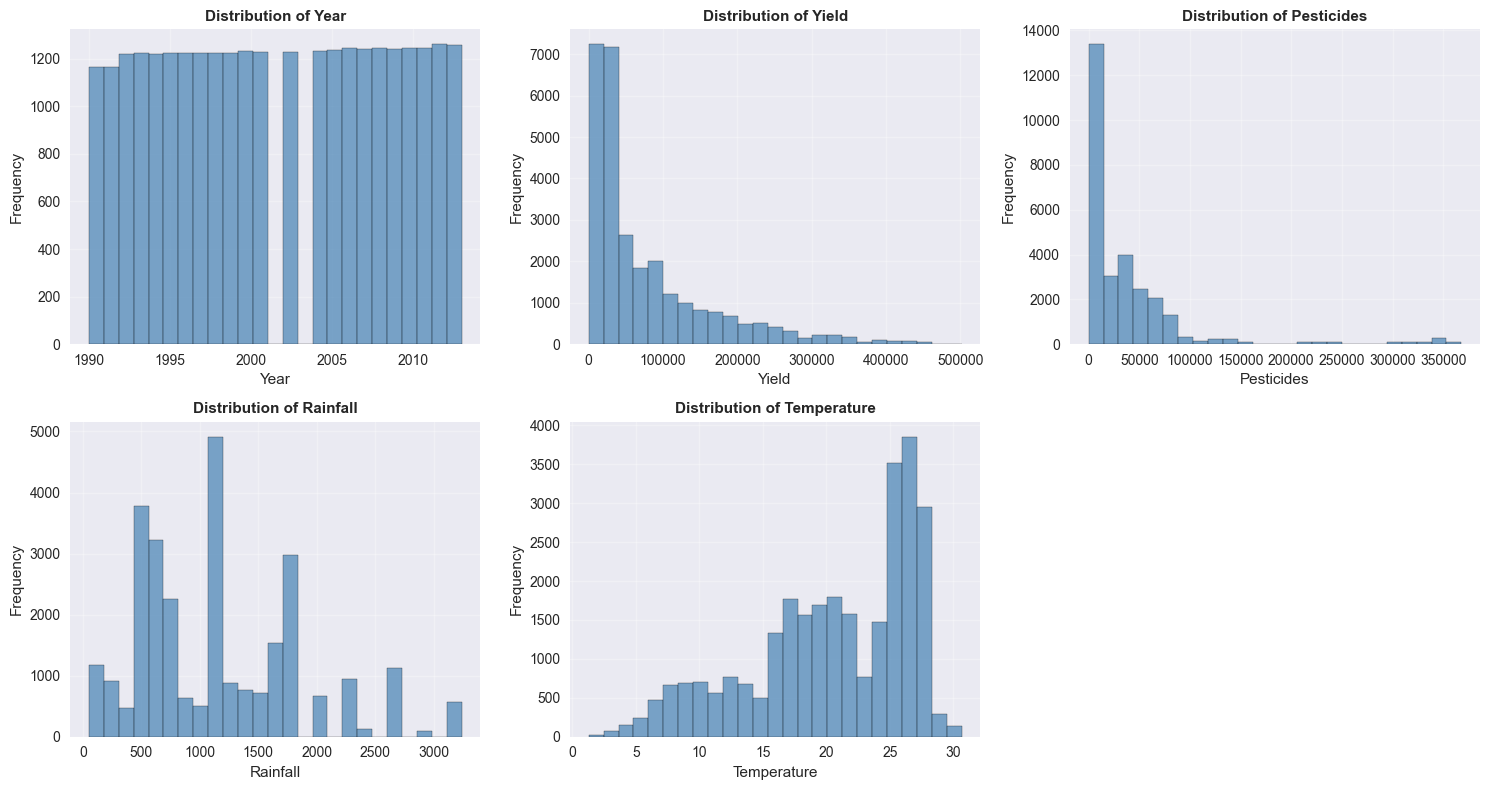

✓ Đã vẽ biểu đồ phân bố cho 5 features


In [35]:
# Phân bố các features numeric
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Vẽ histograms cho từng numeric feature
n_cols = len(numeric_cols)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4*n_rows))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col], bins=25, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)

# Ẩn các subplot không dùng
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

print(f"✓ Đã vẽ biểu đồ phân bố cho {len(numeric_cols)} features")

## 5. Correlation Analysis

In [36]:
# Tính tương quan giữa các features
print("\n" + "="*80)
print("🔗 PHÂN TÍCH TƯƠNG QUAN")
print("="*80)

numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

print(f"\nKích thước Correlation Matrix: {correlation_matrix.shape}")


🔗 PHÂN TÍCH TƯƠNG QUAN

Kích thước Correlation Matrix: (5, 5)


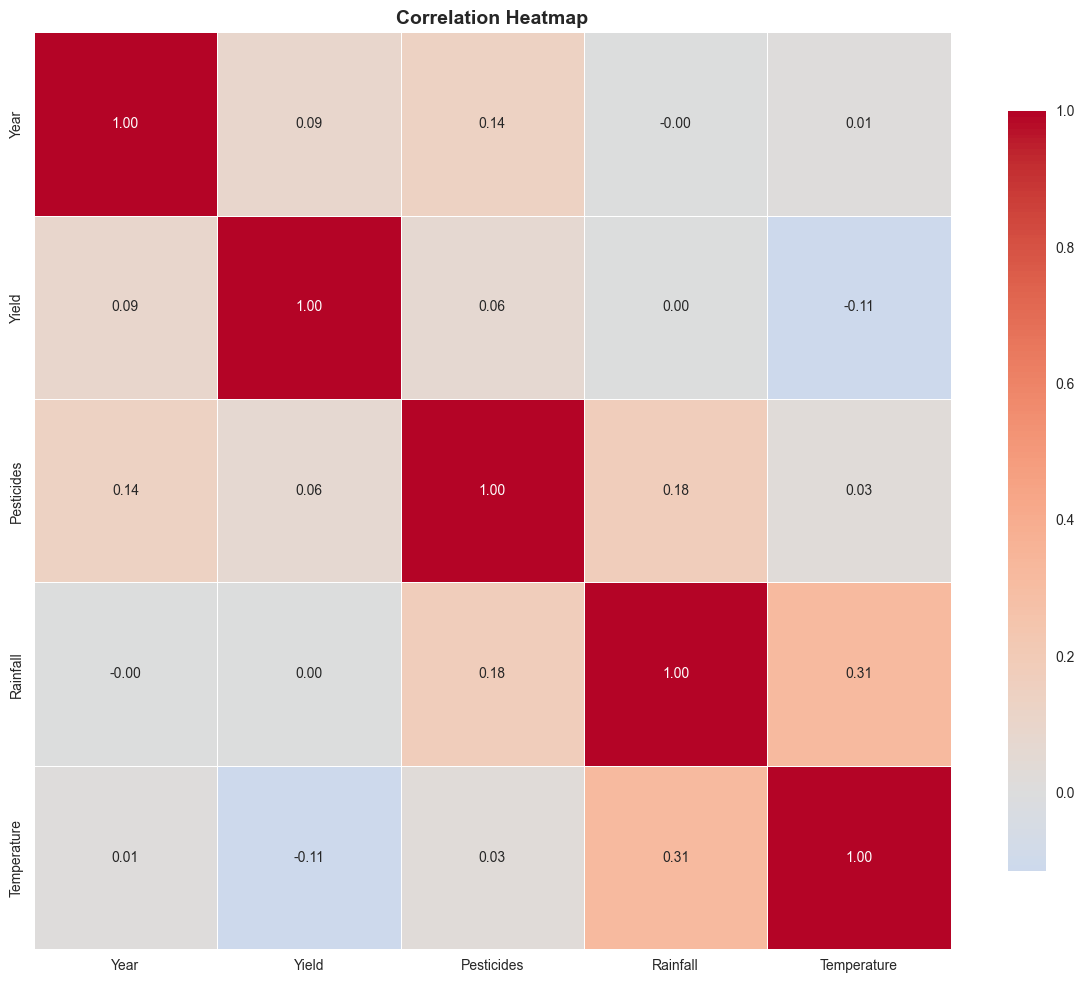

✓ Correlation heatmap đã vẽ


In [37]:
# Vẽ Correlation Heatmap
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, 
            cbar_kws={"shrink": 0.8}, ax=ax)

ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Correlation heatmap đã vẽ")


📊 Tương Quan Của Các Features Với Yield:


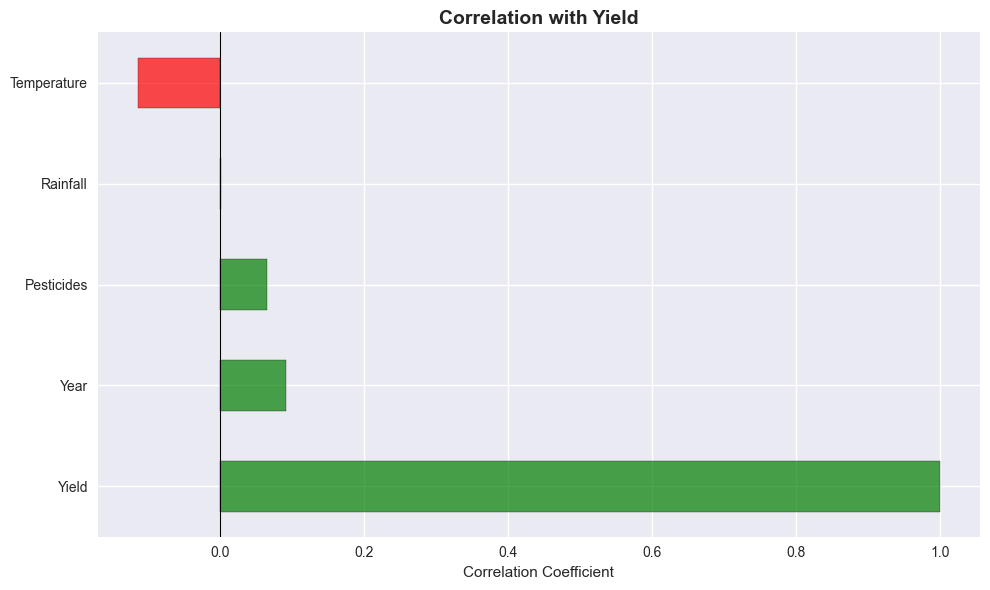


Yield          1.000000
Year           0.091630
Pesticides     0.064085
Rainfall       0.000962
Temperature   -0.114777


In [38]:
# Tìm tương quan với Yield
if 'Yield' in correlation_matrix.columns:
    print("\n📊 Tương Quan Của Các Features Với Yield:")
    
    yield_corr = correlation_matrix['Yield'].sort_values(ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Tô màu các bar
    colors = ['green' if x > 0 else 'red' for x in yield_corr.values]
    
    yield_corr.plot(kind='barh', ax=ax, color=colors, alpha=0.7, edgecolor='black')
    ax.set_title('Correlation with Yield', fontsize=14, fontweight='bold')
    ax.set_xlabel('Correlation Coefficient')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    plt.tight_layout()
    plt.show()
    
    print("\n" + yield_corr.to_string())

## 6. Outlier Detection

In [39]:
# Phát hiện outliers sử dụng IQR method
print("\n" + "="*80)
print("🎯 PHÁT HIỆN OUTLIERS (IQR METHOD)")
print("="*80)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

outlier_info = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    if len(outliers) > 0:
        outlier_info.append({
            'Column': col,
            'Outlier Count': len(outliers),
            'Outlier %': (len(outliers) / len(df) * 100),
            'Lower Bound': lower_bound,
            'Upper Bound': upper_bound
        })

if outlier_info:
    outlier_df = pd.DataFrame(outlier_info)
    display(outlier_df)
else:
    print("✓ Không tìm thấy outliers")


🎯 PHÁT HIỆN OUTLIERS (IQR METHOD)


,Column,Outlier Count,Outlier %,Lower Bound,Upper Bound
0,Yield,2059,7.290560,-107217.00000,231813.00000
1,Pesticides,1418,5.020891,-68776.82000,119166.70000
2,Temperature,34,0.120388,2.75625,39.94625


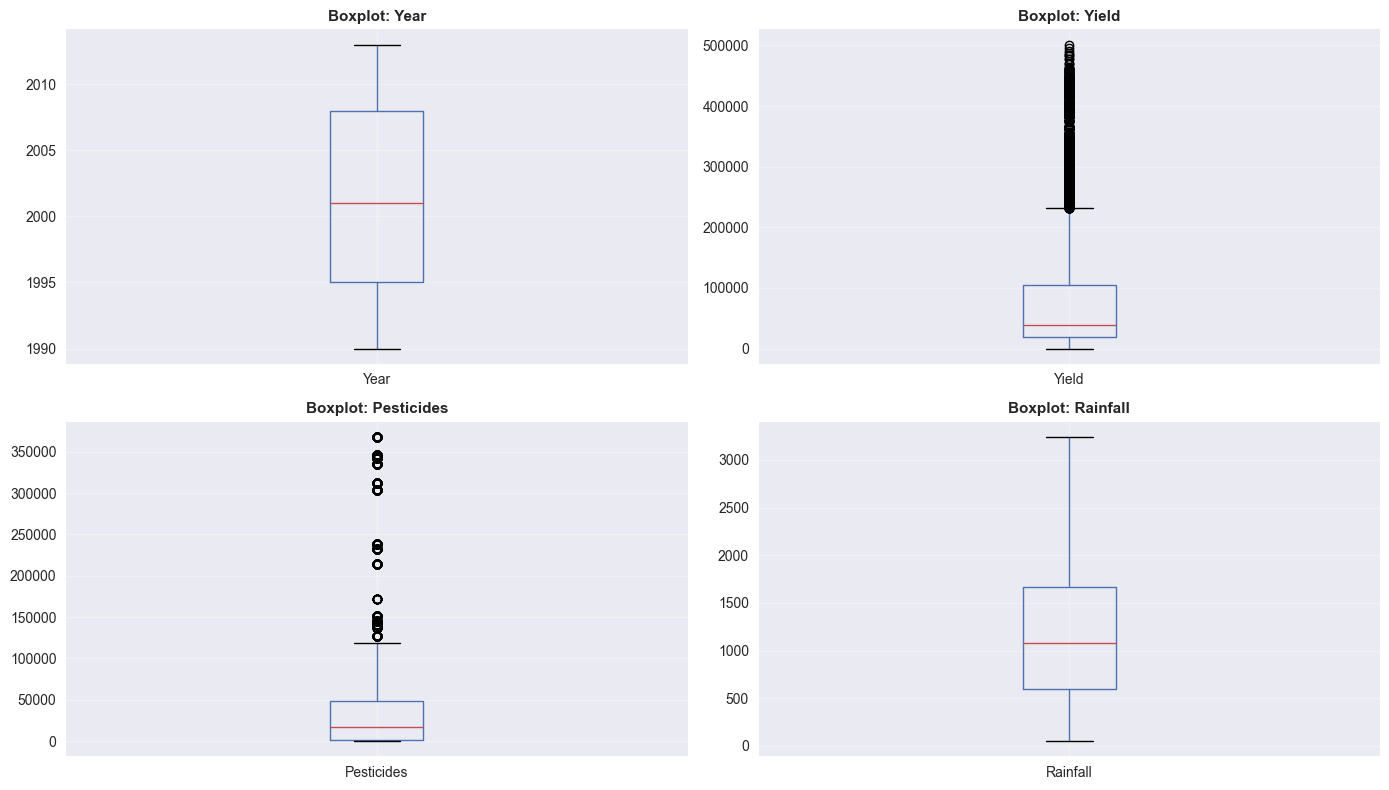

✓ Boxplots đã vẽ


In [40]:
# Vẽ Boxplots để hiển thị outliers
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols[:4]):
    df.boxplot(column=col, ax=axes[idx])
    axes[idx].set_title(f'Boxplot: {col}', fontsize=11, fontweight='bold')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Boxplots đã vẽ")

## 7. Categorical Variables Analysis

In [41]:
# Phân tích các biến categorical
print("\n" + "="*80)
print("🏷️  PHÂN TÍCH BIẾN CATEGORICAL")
print("="*80)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

if categorical_cols:
    for col in categorical_cols:
        print(f"\n{col}:")
        value_counts = df[col].value_counts()
        print(f"  Unique values: {df[col].nunique()}")
        print(f"  Top 5 values:")
        print(value_counts.head())
else:
    print("✓ Không có biến categorical")


🏷️  PHÂN TÍCH BIẾN CATEGORICAL

Area:
  Unique values: 101
  Top 5 values:
Area
India       4048
Brazil      2277
Mexico      1472
Pakistan    1449
Japan        966
Name: count, dtype: int64


## 8. Key Insights and Summary

In [42]:
# Tóm tắt các insights chính
print("\n" + "="*80)
print("💡 TÓM TẮT CÁC INSIGHTS CHÍNH")
print("="*80)

print(f"\n📊 Dataset Overview:")
print(f"   • Số hàng: {df.shape[0]}")
print(f"   • Số cột: {df.shape[1]}")
print(f"   • Missing values: {df.isnull().sum().sum()}")

print(f"\n📈 Target Variable (Yield):")
if 'Yield' in df.columns:
    print(f"   • Mean: {df['Yield'].mean():.2f}")
    print(f"   • Std Dev: {df['Yield'].std():.2f}")
    print(f"   • Min: {df['Yield'].min():.2f}")
    print(f"   • Max: {df['Yield'].max():.2f}")

print(f"\n🔗 Top Correlations with Yield:")
if 'Yield' in correlation_matrix.columns:
    top_corr = correlation_matrix['Yield'].sort_values(ascending=False)[1:6]
    for feat, corr in top_corr.items():
        print(f"   • {feat}: {corr:.4f}")

print(f"\n✓ EDA hoàn tất!")


💡 TÓM TẮT CÁC INSIGHTS CHÍNH

📊 Dataset Overview:
   • Số hàng: 28242
   • Số cột: 6
   • Missing values: 0

📈 Target Variable (Yield):
   • Mean: 77053.33
   • Std Dev: 84956.61
   • Min: 50.00
   • Max: 501412.00

🔗 Top Correlations with Yield:
   • Year: 0.0916
   • Pesticides: 0.0641
   • Rainfall: 0.0010
   • Temperature: -0.1148

✓ EDA hoàn tất!
